In [2]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

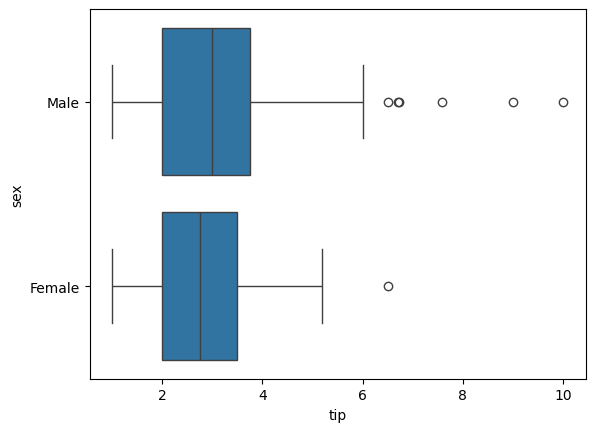

In [4]:
# boxplot
tips = sns.load_dataset("tips")
sns.boxplot(data=tips, x='tip', y='sex');

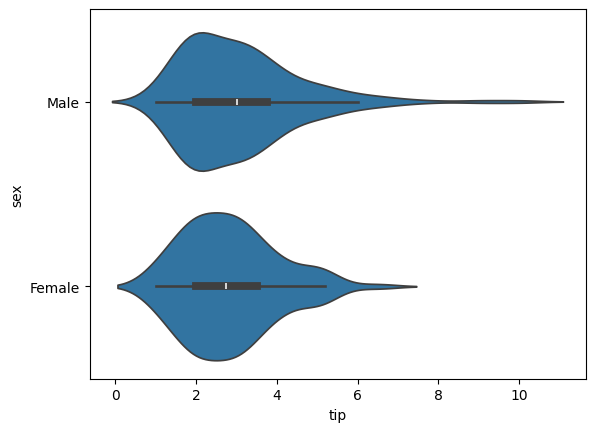

In [5]:
# violinplot
sns.violinplot(data=tips, x='tip', y='sex');

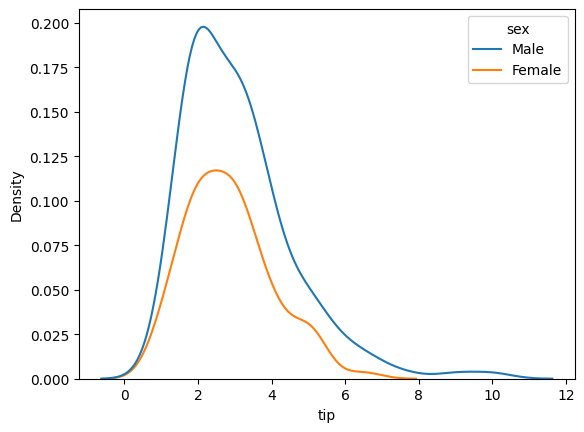

In [6]:
# density plot
sns.kdeplot(data=tips, hue='sex', x='tip');

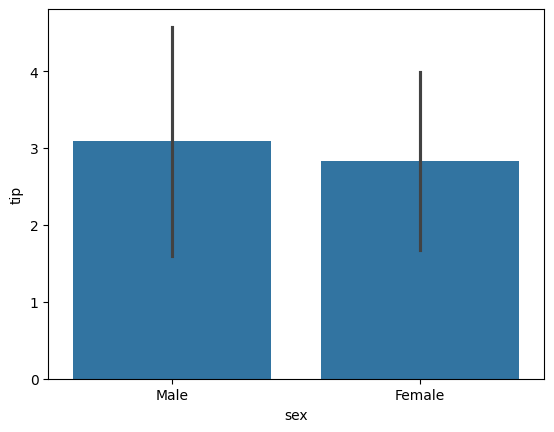

In [7]:
# bar charts with error bars
sns.barplot(data=tips, x='sex', y='tip', errorbar='sd');

# t test independant samples

In [ ]:
tips = sns.load_dataset("tips")
# Sample:
control = np.array([91, 87, 99, 77, 88, 91])
treatment = np.array([101, 110, 103, 93, 99, 104])
# Visualization:
sns.boxplot(
    data=pd.DataFrame({'control': control, 'treatment': treatment}),
    orient='h');
t, p = stats.ttest_ind(a=control, b=treatment, alternative='less', equal_var=False)
print(f"t-value   :   {t:.5f}")
print(f"p-value   :   {p:.5f}")
t, p = stats.ttest_ind(alternative='two-sided', a=tips.tip[tips.sex == 'Male'], b=tips.tip[tips.sex == 'Female'])
print(f"t-value   :   {t:.5f}")
print(f"p-value   :   {p:.5f}")

## stappenplan

> stap 1:  
> $H_0$: er zal geen significant verschil zijn tussen x en y  
> $H_1$: er zal wel een significant verschil zijn tussen x en y

In [ ]:
# stap 2
alpha = 0.05
# stap 3 -> teststatistiek = independant t test
# stap 4 -> p berekenen
t, p = stats.ttest_ind(a=control, b=treatment, alternative='greater', equal_var=False)

print(f"t-value   :   {t:.5f}")
print(f"p-value   :   {p:.5f}")

> stap 5:  
> $p$ $\gt$ $\alpha$ en $g$ $\gt$ $\chi$²  
> Er is niet voldoende aanwijzing om $H_0$ te verwerpen -> correcte sample  
> stap 5:  
> $p$ $\lt$ $\alpha$ en $g$ $\lt$ $\chi$²  
> Er is voldoende aanwijzing om $H_0$ te verwerpen -> correcte sample

# t test paired samples

In [8]:
# Measurements
regular =   np.array([16, 20, 21, 22, 23, 22, 27, 25, 27, 28])
additives = np.array([19, 22, 24, 24, 25, 25, 26, 26, 28, 32])

differences = additives - regular
print(f'Mean difference: {differences.mean():.2f}')
# Paired t-test with ttest_rel()
t, p =stats.ttest_rel(regular, additives, alternative='less')

print(f"t-value   :   {t:.5f}")
print(f"p-value   :   {p:.5f}")

Mean difference: 2.00
t-value   :   -4.47214
p-value   :   0.00077


## stappenplan

> stap 1:  
> $H_0$: er zal geen significant verschil zijn tussen x en y  
> $H_1$: er zal wel een significant verschil zijn tussen x en y

In [ ]:
# stap 2 -> significance level
alpha = 0.05

# stap 3 -> test statistiek (paired 2 sample t test)
# stap 4 -> bereken p
t, p =stats.ttest_rel(regular, additives, alternative='less')

print(f"t-value   :   {t:.5f}")
print(f"p-value   :   {p:.5f}")

> stap 5:  
> $p$ $\gt$ $\alpha$ en $g$ $\gt$ $\chi$²  
> Er is niet voldoende aanwijzing om $H_0$ te verwerpen -> correcte sample  
> stap 5: 
> $p$ $\lt$ $\alpha$ en $g$ $\lt$ $\chi$²  
> Er is voldoende aanwijzing om $H_0$ te verwerpen -> correcte sample

# Effect size (Cohen's $d$)

In [ ]:
def cohen_d(a, b):
    na = len(a)
    nb = len(b)
    pooled_sd = np.sqrt( ((na-1) * np.var(a, ddof=1) +
                          (nb-1) * np.var(b, ddof=1)) / (na + nb - 2) )
    return (np.mean(b) - np.mean(a)) / pooled_sd

In [ ]:
# Effect size for the clinical trial example
cohen_d(control, treatment)